
# Vehicle Plate Detection (Training Pipeline - Google Colab)

Notebook ini **khusus untuk training & evaluasi model deteksi plat nomor**:
1. Setup environment Google Colab
2. Load dataset dari `plate-indo-dataset2026.zip` atau folder `plate-indo-dataset2026`
3. Konversi anotasi ke format YOLO
4. Training model deteksi plat nomor (Ultralytics YOLO)
5. Evaluasi lengkap (loss, precision, recall, mAP, confusion matrix)
6. Simpan artifact model + hasil evaluasi

> Catatan: proses **inference video CCTV + OCR tidak ada di notebook ini**.
> Tahap tersebut dijalankan terpisah lewat script `inference_cctv.py` (lihat bagian akhir notebook).



## 1) Konfigurasi Utama
Ubah parameter di cell ini sesuai kebutuhan eksperimen.


In [ ]:
# =========================
# CONFIG (TRAINING ONLY)
# =========================
USE_GOOGLE_DRIVE = True
DRIVE_MOUNT_POINT = '/content/drive'
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/PlateRecognition'  # sesuaikan

DATASET_ZIP_CANDIDATES = [
    '/content/drive/MyDrive/PlateRecognition/plate-indo-dataset2026.zip',
    '/content/plate-indo-dataset2026.zip',
    './plate-indo-dataset2026.zip',
]

DATASET_DIR_CANDIDATES = [
    '/content/drive/MyDrive/PlateRecognition/plate-indo-dataset2026',
    '/content/plate-indo-dataset2026',
    './plate-indo-dataset2026',
]

WORKSPACE_DIR = '/content/plate_pipeline'
RAW_DATA_DIR = f'{WORKSPACE_DIR}/raw_data'
YOLO_DATASET_DIR = f'{WORKSPACE_DIR}/datasets/plate_yolo'
ARTIFACT_DIR = f'{WORKSPACE_DIR}/artifacts'
RUNS_DIR = f'{WORKSPACE_DIR}/runs'

RANDOM_STATE = 42
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

MODEL_NAME = 'yolov8n.pt'   # ringan untuk Colab
EPOCHS = 10
IMG_SIZE = 640
BATCH_SIZE = 16
DEVICE = 0  # 0 = GPU pertama, atau 'cpu'

CONF_THRESHOLD = 0.65
IOU_THRESHOLD = 0.5


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2) Setup Environment (Dependency + Mount Drive)

In [ ]:

import os
import sys
import subprocess


def pip_install(packages):
    cmd = [sys.executable, '-m', 'pip', 'install', '-q'] + packages
    print('Installing:', ' '.join(packages))
    subprocess.check_call(cmd)

# Dependency versi stabil untuk Colab (Python 3.10/3.11)
# easyocr tidak dibutuhkan di sini: OCR dijalankan di inference_cctv.py
pip_install([
    'ultralytics==8.3.30',
    'opencv-python-headless==4.10.0.84',
    'pandas==2.2.2',
    'seaborn==0.13.2',
    'scikit-learn==1.5.1',
    'lxml==5.3.0',
    'tqdm==4.66.5'
])

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount(DRIVE_MOUNT_POINT, force_remount=False)

for d in [WORKSPACE_DIR, RAW_DATA_DIR, YOLO_DATASET_DIR, ARTIFACT_DIR, RUNS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Workspace ready:', WORKSPACE_DIR)


## 3) Import & Utility Functions

In [17]:
import os
import cv2
import math
import yaml
import glob
import shutil
import random
import zipfile
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from pathlib import Path
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid')


def find_first_existing(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    return None


def ensure_clean_dir(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)


def find_dataset_root(base_path):
    """
    Cari root dataset yang mengandung subfolder images dan annotations.
    Mendukung struktur nested setelah ekstraksi zip.
    """
    base = Path(base_path)
    if not base.exists():
        return None

    # langsung cocok
    if (base / 'images').exists() and (base / 'annotations').exists():
        return str(base)

    # cari nested
    for p in base.rglob('*'):
        if p.is_dir() and (p / 'images').exists() and (p / 'annotations').exists():
            return str(p)

    return None


def detect_annotation_format(dataset_root):
    ann_dir = Path(dataset_root) / 'annotations'
    coco_json = ann_dir / 'annotations.json'
    if coco_json.exists():
        return 'coco'

    xml_files = list(ann_dir.glob('*.xml'))
    if len(xml_files) > 0:
        return 'xml'

    return None


def xyxy_to_yolo(xmin, ymin, xmax, ymax, w, h):
    x_center = ((xmin + xmax) / 2.0) / w
    y_center = ((ymin + ymax) / 2.0) / h
    bw = (xmax - xmin) / w
    bh = (ymax - ymin) / h
    return x_center, y_center, bw, bh


def clamp_bbox(xmin, ymin, xmax, ymax, w, h):
    xmin = max(0, min(xmin, w - 1))
    ymin = max(0, min(ymin, h - 1))
    xmax = max(1, min(xmax, w))
    ymax = max(1, min(ymax, h))
    if xmax <= xmin:
        xmax = min(w, xmin + 1)
    if ymax <= ymin:
        ymax = min(h, ymin + 1)
    return xmin, ymin, xmax, ymax


def resolve_image_path(images_dir, file_name):
    image_path = os.path.join(images_dir, file_name)
    if os.path.exists(image_path):
        return image_path, os.path.basename(file_name)

    stem = Path(file_name).stem
    candidates = glob.glob(os.path.join(images_dir, f'{stem}.*'))
    if len(candidates) == 0:
        return None, None

    candidates = sorted(candidates)
    chosen = candidates[0]
    return chosen, os.path.basename(chosen)


def parse_xml_annotations(images_dir, ann_dir):
    records = []
    xml_files = sorted(glob.glob(os.path.join(ann_dir, '*.xml')))

    for xml_path in tqdm(xml_files, desc='Parsing XML'):
        tree = ET.parse(xml_path)
        root = tree.getroot()

        filename = root.findtext('filename')
        if filename is None:
            filename = Path(xml_path).stem + '.png'

        size = root.find('size')
        if size is None:
            continue

        img_w = int(float(size.findtext('width', default='0')))
        img_h = int(float(size.findtext('height', default='0')))

        image_path, filename = resolve_image_path(images_dir, filename)
        if image_path is None:
            continue

        objs = root.findall('object')
        if len(objs) == 0:
            continue

        for obj in objs:
            cls = obj.findtext('name', default='license_plate')
            bnd = obj.find('bndbox')
            if bnd is None:
                continue

            xmin = int(float(bnd.findtext('xmin', default='0')))
            ymin = int(float(bnd.findtext('ymin', default='0')))
            xmax = int(float(bnd.findtext('xmax', default='0')))
            ymax = int(float(bnd.findtext('ymax', default='0')))

            xmin, ymin, xmax, ymax = clamp_bbox(xmin, ymin, xmax, ymax, img_w, img_h)
            bw = xmax - xmin
            bh = ymax - ymin

            records.append({
                'image_path': image_path,
                'image_name': filename,
                'annotation_path': xml_path,
                'class_name': cls,
                'xmin': xmin,
                'ymin': ymin,
                'xmax': xmax,
                'ymax': ymax,
                'img_w': img_w,
                'img_h': img_h,
                'bbox_w': bw,
                'bbox_h': bh,
                'bbox_area': bw * bh,
                'bbox_aspect': bw / max(1, bh)
            })

    return records


def parse_coco_annotations(images_dir, ann_json_path):
    records = []

    with open(ann_json_path, 'r') as f:
        coco = json.load(f)

    images = coco.get('images', [])
    annotations = coco.get('annotations', [])
    categories = coco.get('categories', [])

    image_map = {img['id']: img for img in images if 'id' in img}
    cat_map = {cat['id']: cat.get('name', 'license_plate') for cat in categories if 'id' in cat}

    for ann in tqdm(annotations, desc='Parsing COCO JSON'):
        image_id = ann.get('image_id')
        img_meta = image_map.get(image_id)
        if img_meta is None:
            continue

        file_name = img_meta.get('file_name', '')
        img_w = int(float(img_meta.get('width', 0)))
        img_h = int(float(img_meta.get('height', 0)))
        if img_w <= 0 or img_h <= 0:
            continue

        image_path, file_name = resolve_image_path(images_dir, file_name)
        if image_path is None:
            continue

        bbox = ann.get('bbox', None)
        if bbox is None or len(bbox) != 4:
            continue

        x, y, w, h = bbox
        xmin = int(round(float(x)))
        ymin = int(round(float(y)))
        xmax = int(round(float(x + w)))
        ymax = int(round(float(y + h)))

        xmin, ymin, xmax, ymax = clamp_bbox(xmin, ymin, xmax, ymax, img_w, img_h)
        bw = xmax - xmin
        bh = ymax - ymin
        if bw <= 0 or bh <= 0:
            continue

        cls = cat_map.get(ann.get('category_id'), 'license_plate')

        records.append({
            'image_path': image_path,
            'image_name': file_name,
            'annotation_path': ann_json_path,
            'class_name': cls,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax,
            'img_w': img_w,
            'img_h': img_h,
            'bbox_w': bw,
            'bbox_h': bh,
            'bbox_area': bw * bh,
            'bbox_aspect': bw / max(1, bh)
        })

    return records


## 4) Load Dataset (ZIP atau Folder) + Validasi Struktur

In [18]:
# 1) Cari dataset zip/folder
found_zip = find_first_existing(DATASET_ZIP_CANDIDATES)
found_dir = find_first_existing(DATASET_DIR_CANDIDATES)

print('Found ZIP :', found_zip)
print('Found DIR :', found_dir)

# 2) Siapkan raw dataset root
raw_extract_dir = os.path.join(RAW_DATA_DIR, 'extracted')
os.makedirs(raw_extract_dir, exist_ok=True)

if found_zip is not None:
    print(f'Extracting ZIP: {found_zip}')
    ensure_clean_dir(raw_extract_dir)
    with zipfile.ZipFile(found_zip, 'r') as zf:
        zf.extractall(raw_extract_dir)
    dataset_root = find_dataset_root(raw_extract_dir)
elif found_dir is not None:
    print(f'Using existing folder: {found_dir}')
    dataset_root = find_dataset_root(found_dir)
else:
    raise FileNotFoundError(
        'Dataset tidak ditemukan. Pastikan salah satu kandidat path ZIP/folder benar.'
    )

if dataset_root is None:
    raise RuntimeError(
        'Struktur dataset tidak valid. Dibutuhkan folder `images/` dan `annotations/`.'
    )

images_dir = os.path.join(dataset_root, 'images')
ann_dir = os.path.join(dataset_root, 'annotations')
annotation_format = detect_annotation_format(dataset_root)

img_files = sorted(glob.glob(os.path.join(images_dir, '*')))
xml_files = sorted(glob.glob(os.path.join(ann_dir, '*.xml')))
ann_json_path = os.path.join(ann_dir, 'annotations.json')

print('\\nDataset root      :', dataset_root)
print('Annotation format :', annotation_format)
print('Images count      :', len(img_files))
print('XML count         :', len(xml_files))
print('COCO JSON exists  :', os.path.exists(ann_json_path))

if len(img_files) == 0:
    raise RuntimeError('Dataset kosong (images tidak ditemukan).')

if annotation_format is None:
    raise RuntimeError(
        'Anotasi tidak valid. Diperlukan `annotations/annotations.json` (COCO) atau `annotations/*.xml`.'
    )


Found ZIP : /content/drive/MyDrive/PlateRecognition/plate-indo-dataset2026.zip
Found DIR : None
Extracting ZIP: /content/drive/MyDrive/PlateRecognition/plate-indo-dataset2026.zip
\nDataset root      : /content/plate_pipeline/raw_data/extracted/plate_detection_dataset/plate_detection_dataset
Annotation format : coco
Images count      : 1383
XML count         : 0
COCO JSON exists  : True


## 5) Parse Annotation XML -> DataFrame (EDA siap penelitian)

In [19]:
if annotation_format == 'coco':
    records = parse_coco_annotations(images_dir, ann_json_path)
elif annotation_format == 'xml':
    records = parse_xml_annotations(images_dir, ann_dir)
else:
    raise RuntimeError(f'Format anotasi tidak didukung: {annotation_format}')

df = pd.DataFrame(records)
if df.empty:
    raise RuntimeError('Tidak ada anotasi valid yang berhasil diparse.')

print('Total bbox:', len(df))
print('Total image unik:', df['image_name'].nunique())
print('\\nClass distribution:')
print(df['class_name'].value_counts())

df.head()


Parsing COCO JSON:   0%|          | 0/2128 [00:00<?, ?it/s]

Total bbox: 2122
Total image unik: 1369
\nClass distribution:
class_name
plate_number    2122
Name: count, dtype: int64


,image_path,image_name,annotation_path,class_name,xmin,ymin,xmax,ymax,img_w,img_h,bbox_w,bbox_h,bbox_area,bbox_aspect
0,/content/plate_pipeline/raw_data/extracted/pla...,Cars00081.png,/content/plate_pipeline/raw_data/extracted/pla...,plate_number,399,402,418,417,1280,720,19,15,285,1.266667
1,/content/plate_pipeline/raw_data/extracted/pla...,Cars00081.png,/content/plate_pipeline/raw_data/extracted/pla...,plate_number,962,408,997,426,1280,720,35,18,630,1.944444
2,/content/plate_pipeline/raw_data/extracted/pla...,Cars00091.png,/content/plate_pipeline/raw_data/extracted/pla...,plate_number,370,486,394,502,1280,720,24,16,384,1.500000
3,/content/plate_pipeline/raw_data/extracted/pla...,Cars00091.png,/content/plate_pipeline/raw_data/extracted/pla...,plate_number,966,412,995,426,1280,720,29,14,406,2.071429
4,/content/plate_pipeline/raw_data/extracted/pla...,Cars00101.png,/content/plate_pipeline/raw_data/extracted/pla...,plate_number,336,609,367,629,1280,720,31,20,620,1.550000


## 6) Statistik & Visualisasi Dataset

In [20]:

# Ringkasan statistik untuk laporan penelitian
stats = {
    'num_images': int(df['image_name'].nunique()),
    'num_boxes': int(len(df)),
    'avg_boxes_per_image': float(len(df) / df['image_name'].nunique()),
    'bbox_width_mean': float(df['bbox_w'].mean()),
    'bbox_height_mean': float(df['bbox_h'].mean()),
    'bbox_area_mean': float(df['bbox_area'].mean()),
}

stats_df = pd.DataFrame([stats])
stats_df


,num_images,num_boxes,avg_boxes_per_image,bbox_width_mean,bbox_height_mean,bbox_area_mean
0,1369,2122,1.550037,97.864279,32.745052,8351.152215


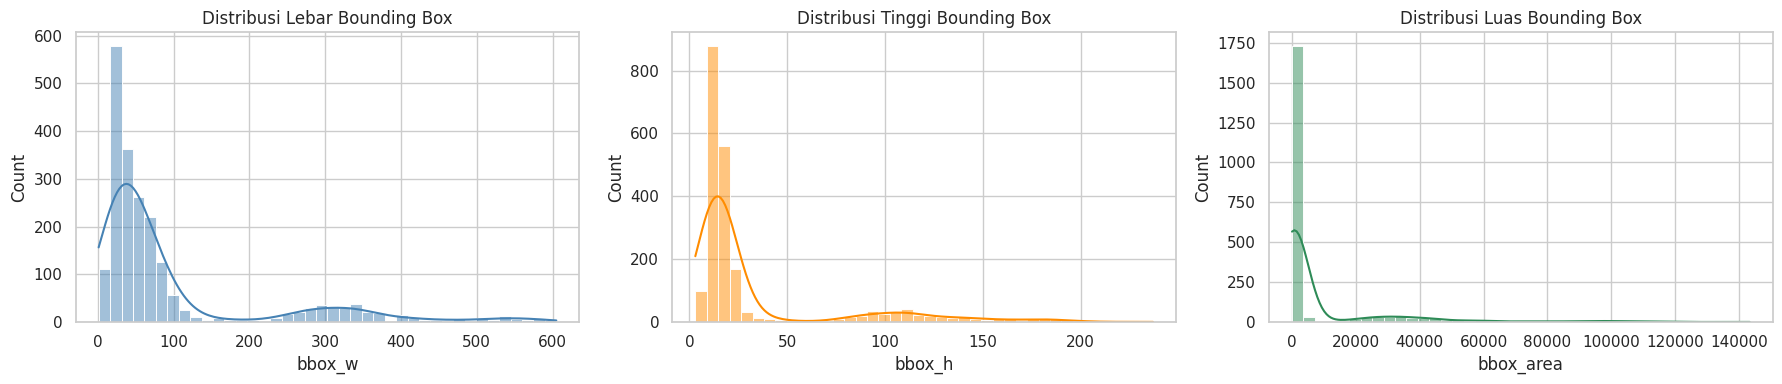

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df['bbox_w'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Lebar Bounding Box')

sns.histplot(df['bbox_h'], bins=40, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribusi Tinggi Bounding Box')

sns.histplot(df['bbox_area'], bins=40, kde=True, ax=axes[2], color='seagreen')
axes[2].set_title('Distribusi Luas Bounding Box')

plt.tight_layout()
plt.show()


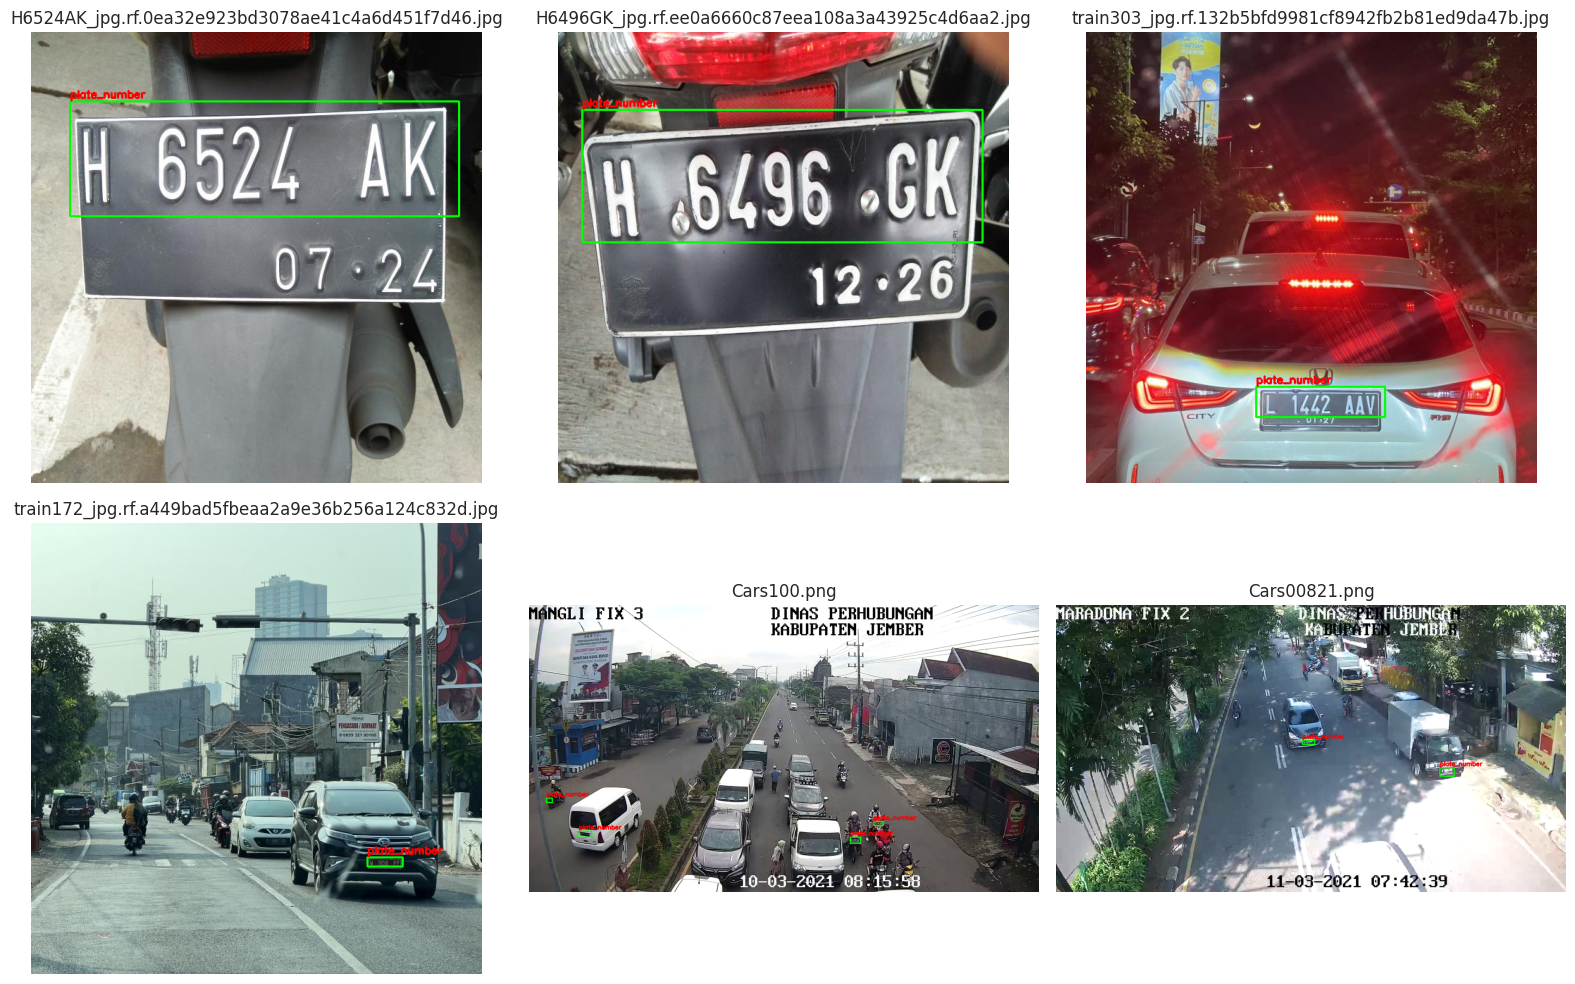

In [22]:

# Tampilkan sampel image + bbox
sample_images = df['image_name'].drop_duplicates().sample(min(6, df['image_name'].nunique()), random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, img_name in zip(axes, sample_images):
    rows = df[df['image_name'] == img_name]
    img = cv2.imread(rows.iloc[0]['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for _, r in rows.iterrows():
        cv2.rectangle(img, (int(r.xmin), int(r.ymin)), (int(r.xmax), int(r.ymax)), (0, 255, 0), 2)
        cv2.putText(img, r.class_name, (int(r.xmin), max(15, int(r.ymin)-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    ax.imshow(img)
    ax.set_title(img_name)
    ax.axis('off')

for i in range(len(sample_images), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


## 7) Split Data + Convert to YOLO Format

In [23]:

# Gunakan image unik untuk split agar tidak bocor antar set
all_images = sorted(df['image_name'].unique())

train_imgs, temp_imgs = train_test_split(
    all_images,
    test_size=(1 - TRAIN_RATIO),
    random_state=RANDOM_STATE,
    shuffle=True
)

relative_val_ratio = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
val_imgs, test_imgs = train_test_split(
    temp_imgs,
    test_size=(1 - relative_val_ratio),
    random_state=RANDOM_STATE,
    shuffle=True
)

split_map = {
    'train': set(train_imgs),
    'val': set(val_imgs),
    'test': set(test_imgs),
}

print({k: len(v) for k, v in split_map.items()})


{'train': 1095, 'val': 137, 'test': 137}


In [24]:
# Buat struktur YOLO dataset
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(YOLO_DATASET_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DATASET_DIR, split, 'labels'), exist_ok=True)

# Mapping kelas ke index
classes = sorted(df['class_name'].unique().tolist())
class_to_id = {c: i for i, c in enumerate(classes)}
print('Class mapping:', class_to_id)

# Grouping annotation per image
grouped = df.groupby('image_name')

for img_name, rows in tqdm(grouped, desc='Converting to YOLO labels'):
    # Tentukan split
    split = None
    for s, sset in split_map.items():
        if img_name in sset:
            split = s
            break
    if split is None:
        continue

    src_img_path = rows.iloc[0]['image_path']
    dst_img_path = os.path.join(YOLO_DATASET_DIR, split, 'images', img_name)
    shutil.copy2(src_img_path, dst_img_path)

    label_path = os.path.join(YOLO_DATASET_DIR, split, 'labels', Path(img_name).stem + '.txt')

    lines = []
    for _, r in rows.iterrows():
        cls_id = class_to_id[r['class_name']]
        x, y, w, h = xyxy_to_yolo(r['xmin'], r['ymin'], r['xmax'], r['ymax'], r['img_w'], r['img_h'])
        lines.append(f'{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}')

    with open(label_path, 'w') as f:
        f.write('\n'.join(lines))

# Simpan data.yaml
yaml_path = os.path.join(YOLO_DATASET_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.safe_dump({
        'path': YOLO_DATASET_DIR,
        'train': 'train/images',
        'val': 'val/images',
        'test': 'test/images',
        'names': {i: c for c, i in class_to_id.items()}
    }, f, sort_keys=False)

print('YOLO dataset ready:', YOLO_DATASET_DIR)
print('YAML:', yaml_path)


Class mapping: {'plate_number': 0}


Converting to YOLO labels:   0%|          | 0/1369 [00:00<?, ?it/s]

YOLO dataset ready: /content/plate_pipeline/datasets/plate_yolo
YAML: /content/plate_pipeline/datasets/plate_yolo/data.yaml


In [25]:

# Cek jumlah image/label tiap split
summary_rows = []
for split in ['train', 'val', 'test']:
    n_img = len(glob.glob(os.path.join(YOLO_DATASET_DIR, split, 'images', '*')))
    n_lbl = len(glob.glob(os.path.join(YOLO_DATASET_DIR, split, 'labels', '*.txt')))
    summary_rows.append({'split': split, 'images': n_img, 'labels': n_lbl})

split_df = pd.DataFrame(summary_rows)
split_df


,split,images,labels
0,train,1095,1095
1,val,137,137
2,test,137,137


## 8) Training YOLO

In [26]:

detector = YOLO(MODEL_NAME)

train_result = detector.train(
    data=os.path.join(YOLO_DATASET_DIR, 'data.yaml'),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    project=RUNS_DIR,
    name='plate_detector',
    exist_ok=True,
    device=DEVICE,
    workers=2,
    verbose=True,
)

print('Training selesai.')


New https://pypi.org/project/ultralytics/8.4.107 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.30 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/plate_pipeline/datasets/plate_yolo/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=2, project=/content/plate_pipeline/runs, name=plate_detector, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None

train: Scanning /content/plate_pipeline/datasets/plate_yolo/train/labels.cache... 1095 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1095/1095 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:1850: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /content/plate_pipeline/datasets/plate_yolo/val/labels.cache... 137 images, 0 backgrounds, 0 corrupt: 100%|██████████| 137/137 [00:00<?, ?it/s]


Plotting labels to /content/plate_pipeline/runs/plate_detector/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /content/plate_pipeline/runs/plate_detector
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


...

      10/10      3.93G      1.065     0.7647     0.9403         12        640: 100%|██████████| 69/69 [00:22<00:00,  3.09it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<00:00,  1.86it/s]

                   all        137        204      0.729       0.74      0.771      0.487



10 epochs completed in 0.075 hours.
Optimizer stripped from /content/plate_pipeline/runs/plate_detector/weights/last.pt, 6.2MB
Optimizer stripped from /content/plate_pipeline/runs/plate_detector/weights/best.pt, 6.2MB

Validating /content/plate_pipeline/runs/plate_detector/weights/best.pt...
Ultralytics 8.3.30 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:02<00:00,  1.68it/s]


                   all        137        204      0.733       0.74      0.767      0.486
Speed: 0.3ms preprocess, 3.4ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to /content/plate_pipeline/runs/plate_detector
Training selesai.


## 9) Evaluasi Model + Visualisasi Kurva

In [27]:

run_dir = os.path.join(RUNS_DIR, 'plate_detector')
best_model_path = os.path.join(run_dir, 'weights', 'best.pt')
last_model_path = os.path.join(run_dir, 'weights', 'last.pt')

print('Best model:', best_model_path, os.path.exists(best_model_path))
print('Last model:', last_model_path, os.path.exists(last_model_path))

best_detector = YOLO(best_model_path)
val_result = best_detector.val(
    data=os.path.join(YOLO_DATASET_DIR, 'data.yaml'),
    split='test',
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    project=RUNS_DIR,
    name='plate_detector_eval_test',
    exist_ok=True,
)

print('Evaluation selesai (split=test).')


Best model: /content/plate_pipeline/runs/plate_detector/weights/best.pt True
Last model: /content/plate_pipeline/runs/plate_detector/weights/last.pt True
Ultralytics 8.3.30 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/plate_pipeline/datasets/plate_yolo/test/labels... 137 images, 0 backgrounds, 0 corrupt: 100%|██████████| 137/137 [00:00<00:00, 652.09it/s]

val: New cache created: /content/plate_pipeline/datasets/plate_yolo/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:04<00:00,  2.19it/s]


                   all        137        221      0.943      0.376      0.667       0.52
Speed: 0.7ms preprocess, 7.2ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/plate_pipeline/runs/plate_detector_eval_test
Evaluation selesai (split=test).


## 9b) Klasifikasi Report Lengkap (Precision, Recall, F1, Accuracy)
Evaluasi ini menghitung metrik klasifikasi berbasis hasil deteksi pada split `test` dengan matching IoU.

Building classification labels:   0%|          | 0/137 [00:00<?, ?it/s]

===== Classification Report (Detection-aware) =====
              precision    recall  f1-score   support

plate_number     0.9740    0.3394    0.5034       221
  background     0.0000    0.0000    0.0000         2

    accuracy                         0.3363       223
   macro avg     0.4870    0.1697    0.2517       223
weighted avg     0.9653    0.3363    0.4988       223

Accuracy : 0.3363
Micro Avg: P=0.3363, R=0.3363, F1=0.3363
Macro Avg: P=0.4870, R=0.1697, F1=0.2517
Weighted : P=0.9653, R=0.3363, F1=0.4988


,precision,recall,f1-score,support
plate_number,0.974026,0.339367,0.503356,221.000000
background,0.000000,0.000000,0.000000,2.000000
accuracy,0.336323,0.336323,0.336323,0.336323
macro avg,0.487013,0.169683,0.251678,223.000000
weighted avg,0.965290,0.336323,0.498841,223.000000


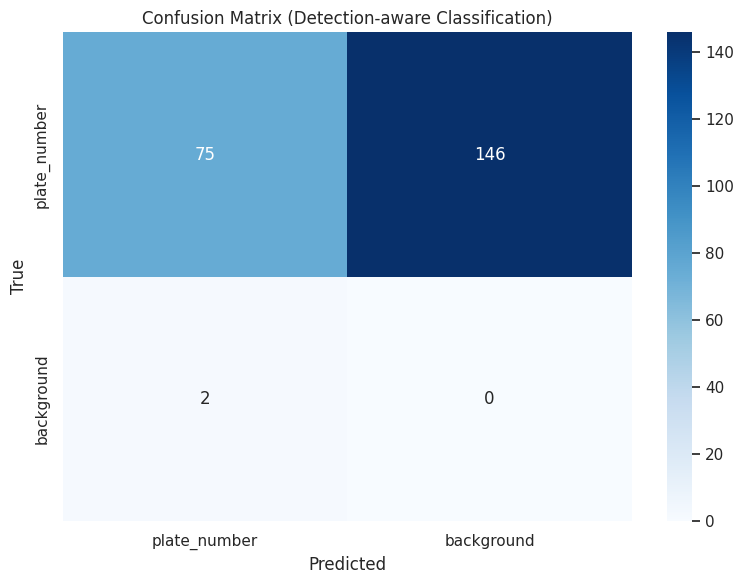

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score

def yolo_txt_to_xyxy(label_path, img_w, img_h):
    boxes = []
    if not os.path.exists(label_path):
        return boxes

    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls_id = int(float(parts[0]))
            x_c, y_c, bw, bh = map(float, parts[1:])

            xmin = int((x_c - bw / 2) * img_w)
            ymin = int((y_c - bh / 2) * img_h)
            xmax = int((x_c + bw / 2) * img_w)
            ymax = int((y_c + bh / 2) * img_h)

            xmin, ymin, xmax, ymax = clamp_bbox(xmin, ymin, xmax, ymax, img_w, img_h)
            boxes.append({'cls_id': cls_id, 'bbox': (xmin, ymin, xmax, ymax)})

    return boxes


def bbox_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    union = area_a + area_b - inter_area

    if union <= 0:
        return 0.0
    return inter_area / union


def evaluate_detection_classification(test_images_dir, test_labels_dir, model, class_names, conf_thr=0.25, iou_thr=0.5):
    background = 'background'
    y_true = []
    y_pred = []

    image_paths = sorted(glob.glob(os.path.join(test_images_dir, '*')))

    for img_path in tqdm(image_paths, desc='Building classification labels'):
        img = cv2.imread(img_path)
        if img is None:
            continue

        h, w = img.shape[:2]
        stem = Path(img_path).stem
        label_path = os.path.join(test_labels_dir, stem + '.txt')

        gt = yolo_txt_to_xyxy(label_path, w, h)

        pred_result = model.predict(img, conf=conf_thr, iou=iou_thr, verbose=False)[0]
        preds = []
        if pred_result.boxes is not None and len(pred_result.boxes) > 0:
            xyxy = pred_result.boxes.xyxy.cpu().numpy()
            cls_ids = pred_result.boxes.cls.cpu().numpy().astype(int)

            for p_box, p_cls in zip(xyxy, cls_ids):
                x1, y1, x2, y2 = map(int, p_box.tolist())
                x1, y1, x2, y2 = clamp_bbox(x1, y1, x2, y2, w, h)
                preds.append({'cls_id': int(p_cls), 'bbox': (x1, y1, x2, y2)})

        matched_gt = set()
        matched_pred = set()

        # Greedy matching berdasarkan IoU tertinggi
        pairs = []
        for gi, g in enumerate(gt):
            for pi, p in enumerate(preds):
                iou = bbox_iou_xyxy(g['bbox'], p['bbox'])
                if iou >= iou_thr:
                    pairs.append((iou, gi, pi))

        pairs.sort(reverse=True, key=lambda x: x[0])

        for _, gi, pi in pairs:
            if gi in matched_gt or pi in matched_pred:
                continue
            matched_gt.add(gi)
            matched_pred.add(pi)

            gt_cls = class_names[gt[gi]['cls_id']] if gt[gi]['cls_id'] < len(class_names) else str(gt[gi]['cls_id'])
            pred_cls = class_names[preds[pi]['cls_id']] if preds[pi]['cls_id'] < len(class_names) else str(preds[pi]['cls_id'])
            y_true.append(gt_cls)
            y_pred.append(pred_cls)

        # False Negative: GT tidak terdeteksi
        for gi, g in enumerate(gt):
            if gi not in matched_gt:
                gt_cls = class_names[g['cls_id']] if g['cls_id'] < len(class_names) else str(g['cls_id'])
                y_true.append(gt_cls)
                y_pred.append(background)

        # False Positive: Prediksi tanpa pasangan GT
        for pi, p in enumerate(preds):
            if pi not in matched_pred:
                pred_cls = class_names[p['cls_id']] if p['cls_id'] < len(class_names) else str(p['cls_id'])
                y_true.append(background)
                y_pred.append(pred_cls)

    labels = class_names + [background]

    report_text = classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=labels,
        zero_division=0,
        digits=4
    )

    report_dict = classification_report(
        y_true, y_pred,
        labels=labels,
        target_names=labels,
        zero_division=0,
        output_dict=True
    )

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    acc = accuracy_score(y_true, y_pred)
    p_micro, r_micro, f1_micro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='micro', zero_division=0
    )
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'labels': labels,
        'classification_report_text': report_text,
        'classification_report_dict': report_dict,
        'confusion_matrix': cm,
        'accuracy': acc,
        'micro': {'precision': p_micro, 'recall': r_micro, 'f1': f1_micro},
        'macro': {'precision': p_macro, 'recall': r_macro, 'f1': f1_macro},
        'weighted': {'precision': p_weighted, 'recall': r_weighted, 'f1': f1_weighted},
        'num_samples': len(y_true),
    }


eval_cls = evaluate_detection_classification(
    test_images_dir=os.path.join(YOLO_DATASET_DIR, 'test', 'images'),
    test_labels_dir=os.path.join(YOLO_DATASET_DIR, 'test', 'labels'),
    model=best_detector,
    class_names=classes,
    conf_thr=CONF_THRESHOLD,
    iou_thr=IOU_THRESHOLD
)

print('===== Classification Report (Detection-aware) =====')
print(eval_cls['classification_report_text'])
print(f"Accuracy : {eval_cls['accuracy']:.4f}")
print(f"Micro Avg: P={eval_cls['micro']['precision']:.4f}, R={eval_cls['micro']['recall']:.4f}, F1={eval_cls['micro']['f1']:.4f}")
print(f"Macro Avg: P={eval_cls['macro']['precision']:.4f}, R={eval_cls['macro']['recall']:.4f}, F1={eval_cls['macro']['f1']:.4f}")
print(f"Weighted : P={eval_cls['weighted']['precision']:.4f}, R={eval_cls['weighted']['recall']:.4f}, F1={eval_cls['weighted']['f1']:.4f}")

report_df = pd.DataFrame(eval_cls['classification_report_dict']).T
display(report_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    eval_cls['confusion_matrix'],
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=eval_cls['labels'],
    yticklabels=eval_cls['labels']
)
plt.title('Confusion Matrix (Detection-aware Classification)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
9,6,165.693,1.26915,1.03701,1.02530,0.77412,0.65519,0.72028,0.44868,1.19774,0.91499,1.00259,0.001010,0.001010,0.001010
10,7,191.682,1.17753,0.92297,0.99346,0.82157,0.69972,0.76748,0.47093,1.19002,0.79909,0.99955,0.000812,0.000812,0.000812
11,8,216.172,1.15616,0.86350,0.98139,0.77709,0.70065,0.75873,0.47391,1.12663,0.76039,0.97650,0.000614,0.000614,0.000614
12,9,242.095,1.11323,0.81542,0.96593,0.76746,0.72801,0.75246,0.48333,1.13380,0.74845,0.96665,0.000416,0.000416,0.000416
13,10,268.270,1.06546,0.76472,0.94030,0.72921,0.74020,0.77131,0.48650,1.12603,0.74088,0.96216,0.000218,0.000218,0.000218


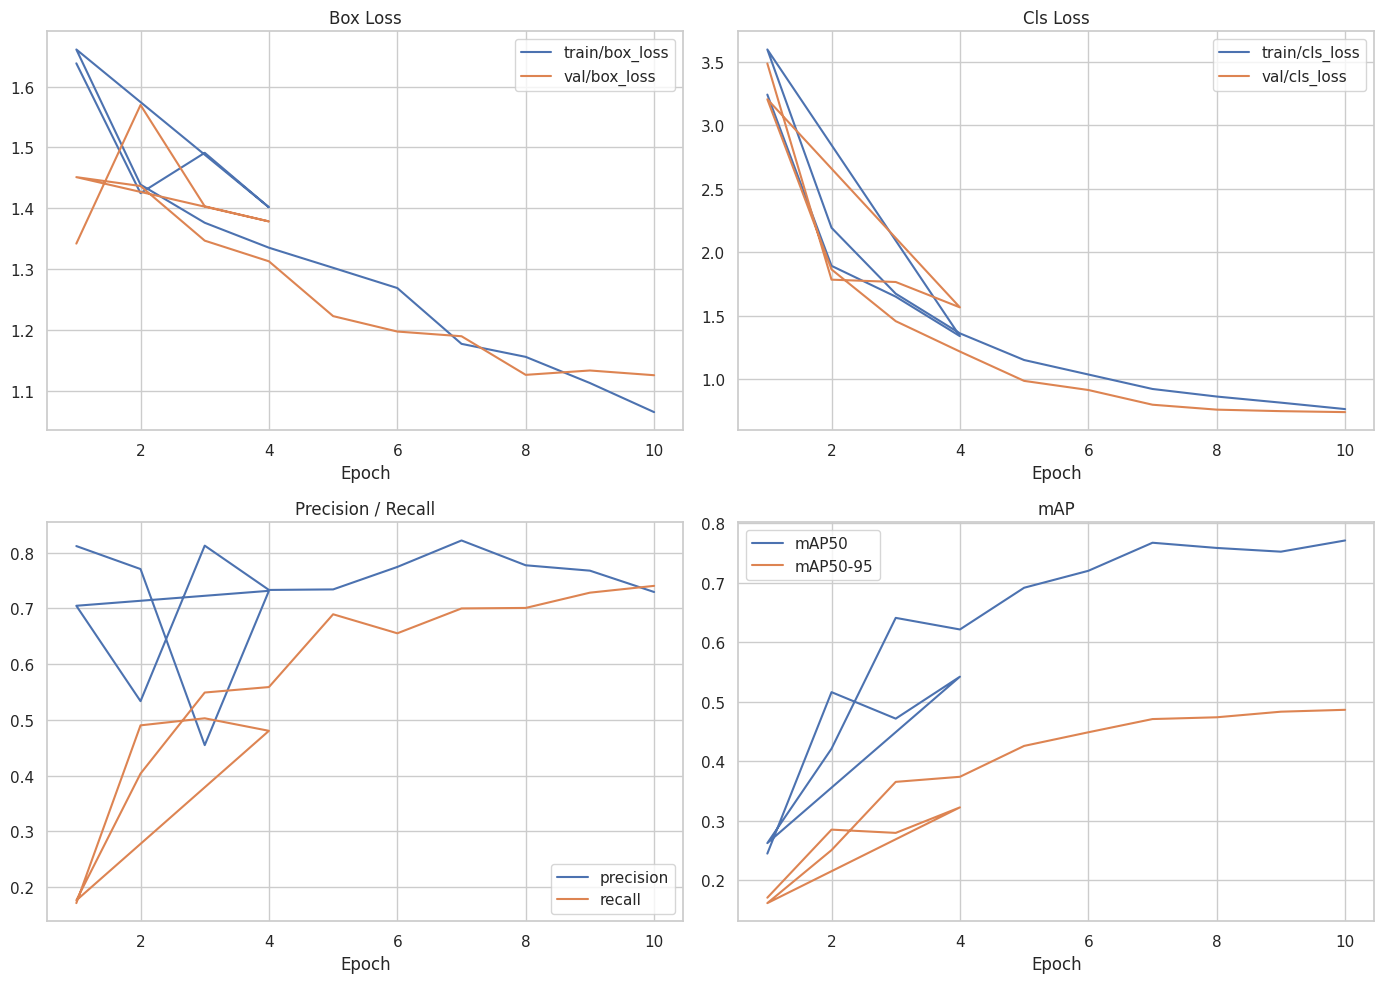

In [29]:

# Plot training curves dari results.csv
results_csv = os.path.join(run_dir, 'results.csv')
if os.path.exists(results_csv):
    hist = pd.read_csv(results_csv)
    display(hist.tail())

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    if 'train/box_loss' in hist.columns and 'val/box_loss' in hist.columns:
        axes[0, 0].plot(hist['epoch'], hist['train/box_loss'], label='train/box_loss')
        axes[0, 0].plot(hist['epoch'], hist['val/box_loss'], label='val/box_loss')
        axes[0, 0].set_title('Box Loss')
        axes[0, 0].legend()

    if 'train/cls_loss' in hist.columns and 'val/cls_loss' in hist.columns:
        axes[0, 1].plot(hist['epoch'], hist['train/cls_loss'], label='train/cls_loss')
        axes[0, 1].plot(hist['epoch'], hist['val/cls_loss'], label='val/cls_loss')
        axes[0, 1].set_title('Cls Loss')
        axes[0, 1].legend()

    if 'metrics/precision(B)' in hist.columns and 'metrics/recall(B)' in hist.columns:
        axes[1, 0].plot(hist['epoch'], hist['metrics/precision(B)'], label='precision')
        axes[1, 0].plot(hist['epoch'], hist['metrics/recall(B)'], label='recall')
        axes[1, 0].set_title('Precision / Recall')
        axes[1, 0].legend()

    if 'metrics/mAP50(B)' in hist.columns and 'metrics/mAP50-95(B)' in hist.columns:
        axes[1, 1].plot(hist['epoch'], hist['metrics/mAP50(B)'], label='mAP50')
        axes[1, 1].plot(hist['epoch'], hist['metrics/mAP50-95(B)'], label='mAP50-95')
        axes[1, 1].set_title('mAP')
        axes[1, 1].legend()

    for ax in axes.flatten():
        ax.set_xlabel('Epoch')

    plt.tight_layout()
    plt.show()
else:
    print('results.csv tidak ditemukan:', results_csv)


Found assets: 7


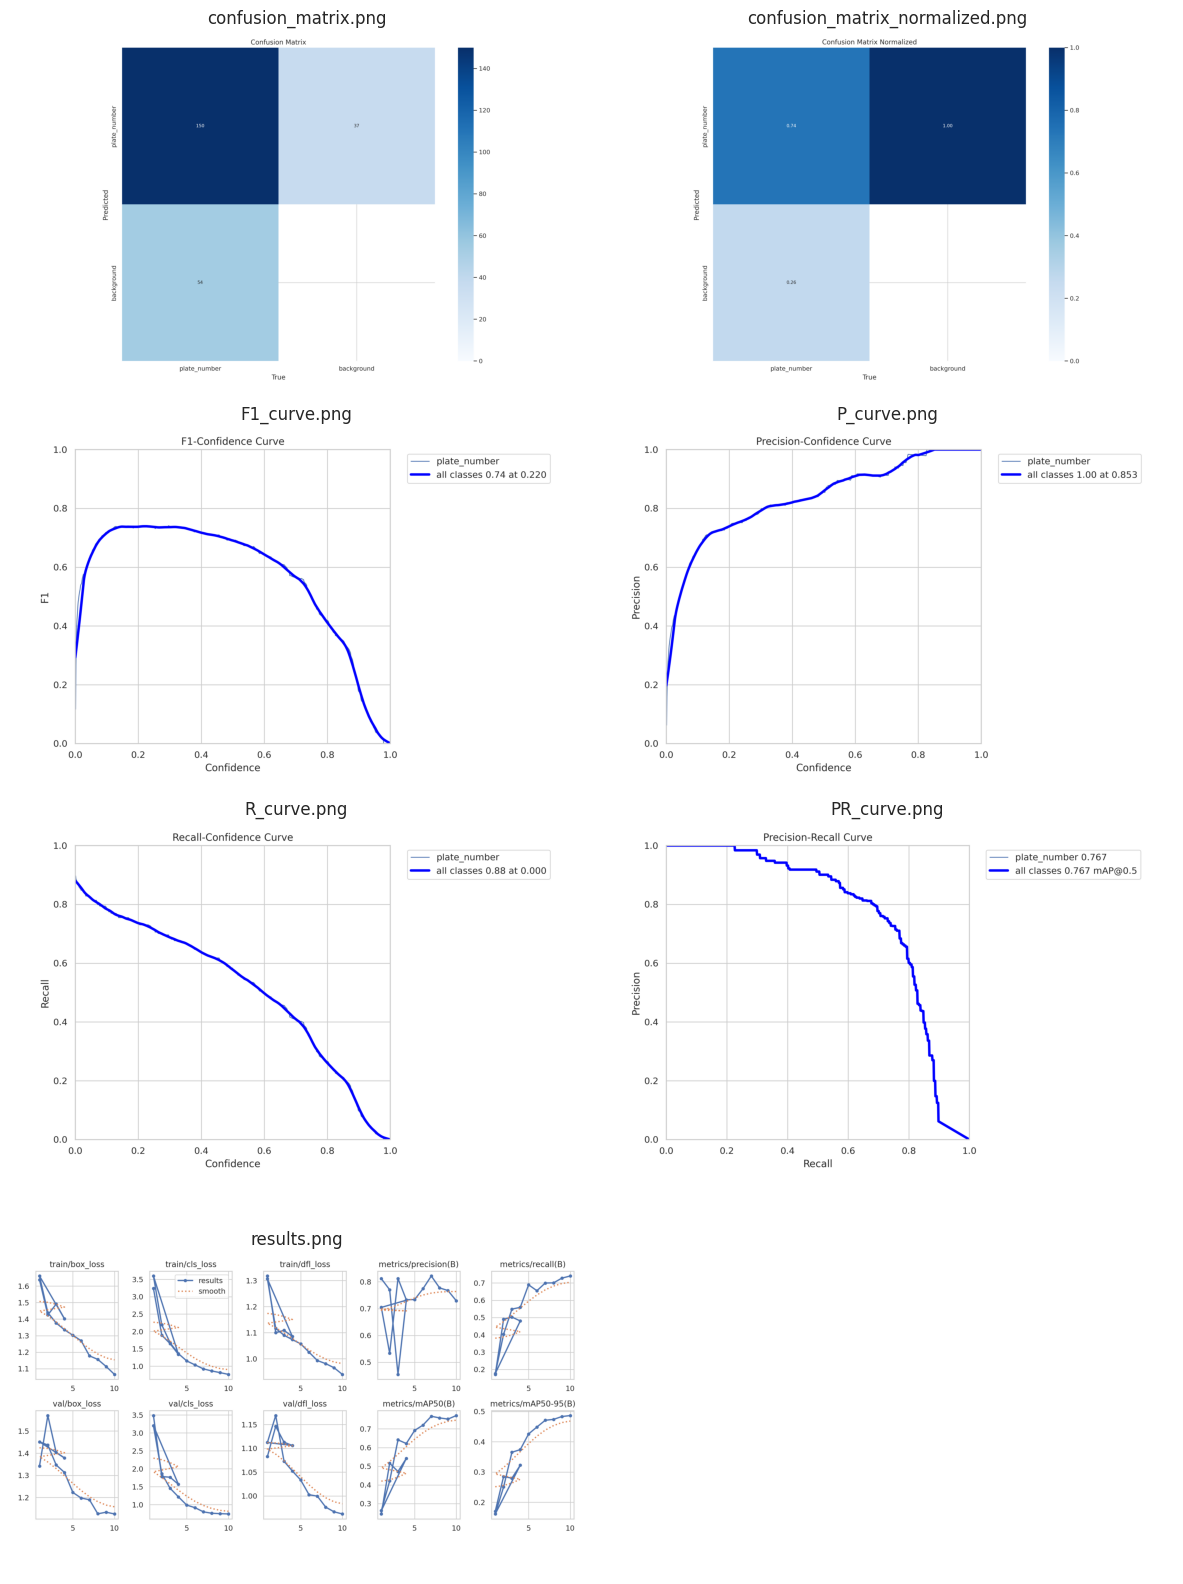

In [30]:

# Tampilkan gambar evaluasi jika tersedia
eval_assets = [
    os.path.join(run_dir, 'confusion_matrix.png'),
    os.path.join(run_dir, 'confusion_matrix_normalized.png'),
    os.path.join(run_dir, 'F1_curve.png'),
    os.path.join(run_dir, 'P_curve.png'),
    os.path.join(run_dir, 'R_curve.png'),
    os.path.join(run_dir, 'PR_curve.png'),
    os.path.join(run_dir, 'results.png'),
]

existing_assets = [p for p in eval_assets if os.path.exists(p)]
print('Found assets:', len(existing_assets))

if existing_assets:
    n = len(existing_assets)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for i, p in enumerate(existing_assets):
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(Path(p).name)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


## 10) Contoh Prediksi Benar/Salah (Visual)

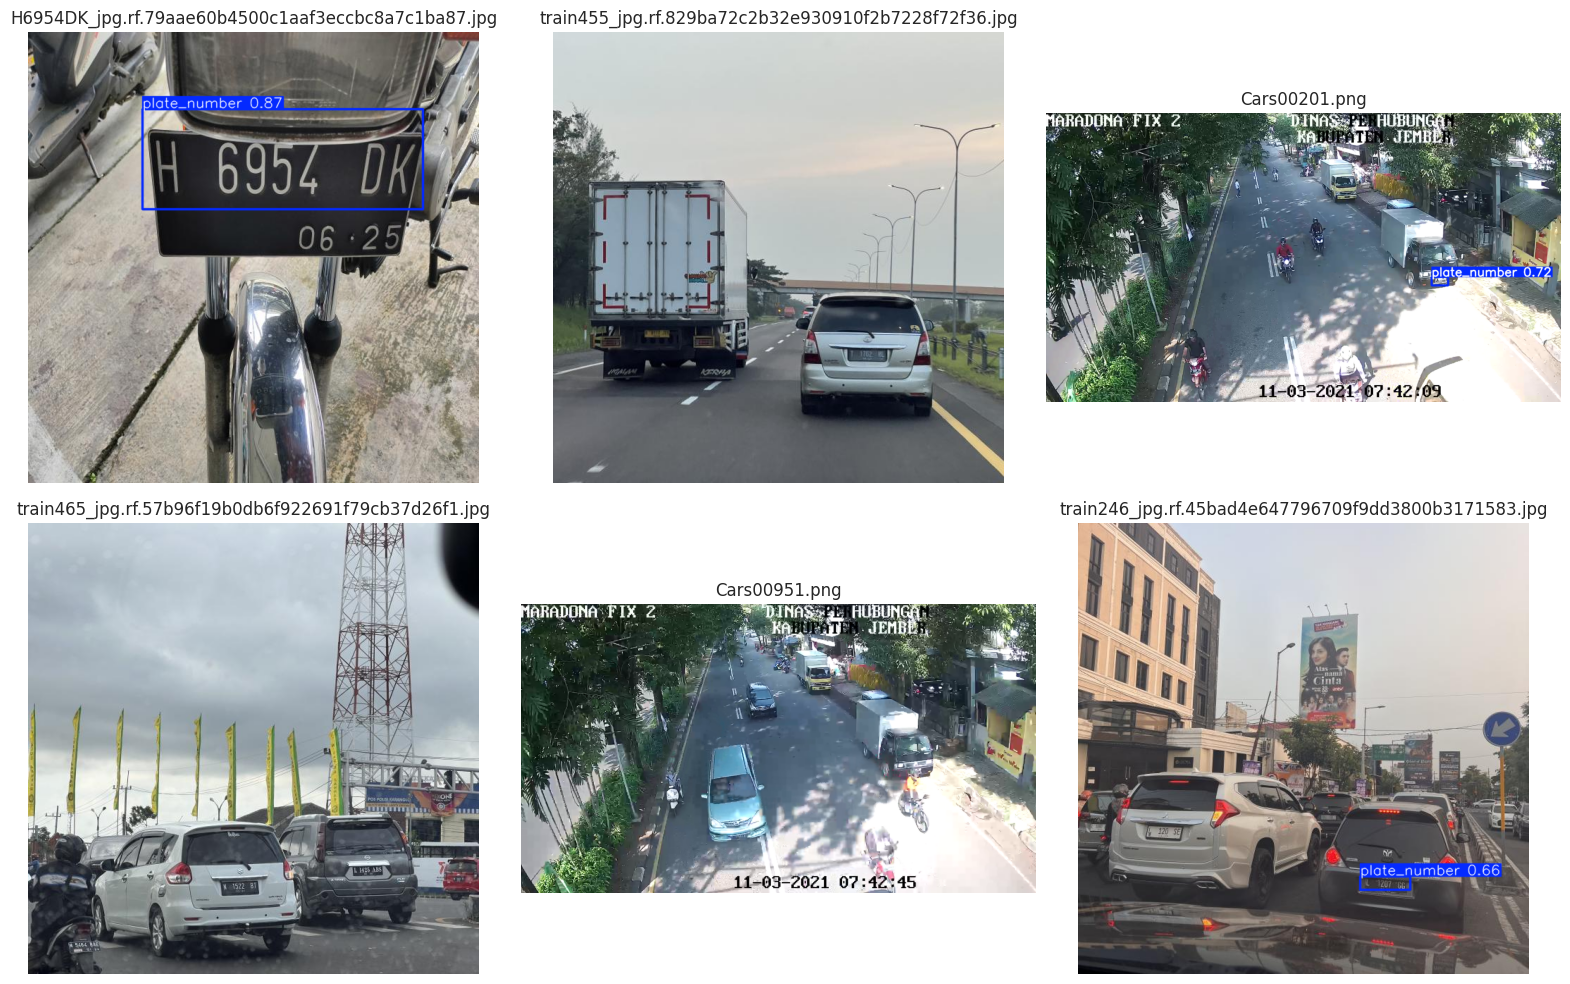

In [31]:

# Visualisasi prediksi di sample test images
sample_test_images = glob.glob(os.path.join(YOLO_DATASET_DIR, 'test', 'images', '*'))
random.shuffle(sample_test_images)
sample_test_images = sample_test_images[:6]

pred_vis_dir = os.path.join(ARTIFACT_DIR, 'sample_predictions')
os.makedirs(pred_vis_dir, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_test_images):
    res = best_detector.predict(img_path, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)[0]
    vis = res.plot()
    vis = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    ax.imshow(vis)
    ax.set_title(Path(img_path).name)
    ax.axis('off')

for i in range(len(sample_test_images), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


## 11) Export Artifact Penting (Model + Data + Hasil)

In [ ]:

# Artifact utama hasil training / evaluasi
artifact_main = {
    'best_model': best_model_path,
    'last_model': last_model_path,
    'data_yaml': os.path.join(YOLO_DATASET_DIR, 'data.yaml'),
    'training_run_dir': run_dir,
    'results_csv': os.path.join(run_dir, 'results.csv'),
    'eval_test_dir': os.path.join(RUNS_DIR, 'plate_detector_eval_test'),
    'sample_predictions': os.path.join(ARTIFACT_DIR, 'sample_predictions'),
}

artifact_df = pd.DataFrame([
    {'artifact_name': k, 'path': v, 'exists': os.path.exists(v)}
    for k, v in artifact_main.items()
])

artifact_df


In [ ]:

# (Opsional) Salin artifact ke Google Drive untuk backup permanen
if USE_GOOGLE_DRIVE:
    export_dir = os.path.join(DRIVE_PROJECT_DIR, 'artifacts_export')
    os.makedirs(export_dir, exist_ok=True)

    to_copy = [
        best_model_path,
        last_model_path,
        os.path.join(run_dir, 'results.csv'),
    ]

    for src_path in to_copy:
        if os.path.exists(src_path):
            dst = os.path.join(export_dir, os.path.basename(src_path))
            shutil.copy2(src_path, dst)
            print('Copied:', dst)

    # Copy training summary images jika ada
    for png_name in ['results.png', 'confusion_matrix.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png', 'F1_curve.png']:
        src_path = os.path.join(run_dir, png_name)
        if os.path.exists(src_path):
            dst = os.path.join(export_dir, png_name)
            shutil.copy2(src_path, dst)
            print('Copied:', dst)

    print('Export selesai ->', export_dir)


## 12) Struktur Project Sederhana (Prototype Platform)

In [ ]:

project_tree = f"""
{WORKSPACE_DIR}/
|- raw_data/
|  |- extracted/                      # hasil ekstrak dataset jika input zip
|- datasets/
|  |- plate_yolo/
|     |- data.yaml
|     |- train/images, train/labels
|     |- val/images, val/labels
|     |- test/images, test/labels
|- runs/
|  |- plate_detector/
|     |- weights/best.pt              # artifact utama model deteksi
|     |- weights/last.pt
|     |- results.csv, results.png, PR_curve.png, confusion_matrix.png, dll
|  |- plate_detector_eval_test/        # hasil evaluasi split test
|- artifacts/
|  |- sample_predictions/             # visualisasi prediksi pada sample test
"""

print(project_tree)



## 13) Catatan Penggunaan Artifact Utama
- Artifact model utama hasil notebook ini adalah: `runs/plate_detector/weights/best.pt`
- Jika ingin reproduksi eksperimen, simpan juga: `data.yaml`, `results.csv`, dan seluruh folder `runs/plate_detector`.

### Tahap Inference CCTV + OCR (di luar notebook)
Notebook ini berhenti di training + evaluasi. Untuk memproses video CCTV (`cctv.mp4`)
menjadi video anotasi, log OCR, dan evidence frame, unduh `best.pt` lalu jalankan script terpisah:

```bash
python inference_cctv.py \
  --model best.pt \
  --video cctv.mp4 \
  --out-video artifacts/cctv_plate_annotated.mp4 \
  --out-csv artifacts/cctv_plate_ocr_log.csv \
  --evidence-dir artifacts/evidence_frames
```

Atau gunakan dashboard web `app.py` untuk upload video dan melihat hasilnya.
